In [3]:
import pandas as pd
df = pd.read_csv('dataset_task1.csv')

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [5]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [15]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [17]:
#filling missing values using mean
mean_value = df['TotalCharges'].mean()
df['TotalCharges'] = df['TotalCharges'].fillna(mean_value)

In [19]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

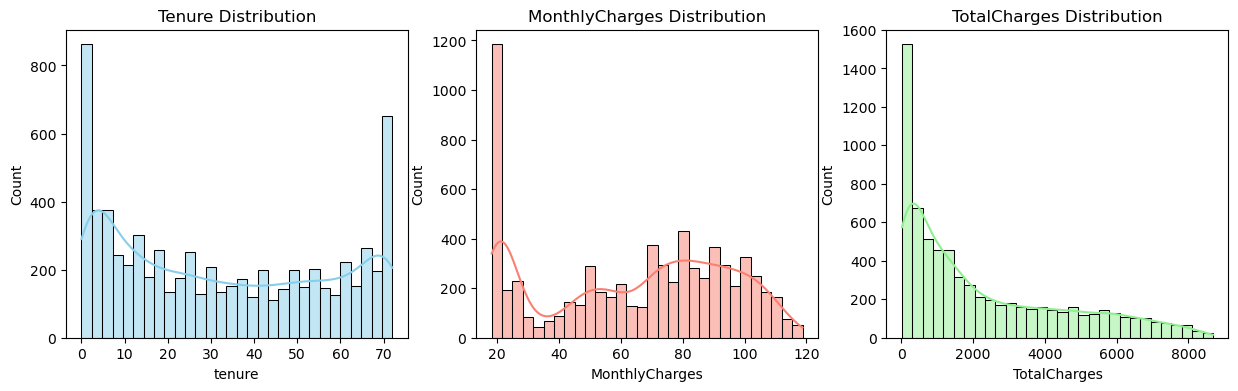

In [34]:
#histograms for numerical data
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(df["tenure"], kde=True, bins=30, ax=axes[0], color="skyblue")
axes[0].set_title("Tenure Distribution")

sns.histplot(df["MonthlyCharges"], kde=True, bins=30, ax=axes[1], color="salmon")
axes[1].set_title("MonthlyCharges Distribution")

sns.histplot(df["TotalCharges"].dropna(), kde=True, bins=30, ax=axes[2], color="lightgreen")
axes[2].set_title("TotalCharges Distribution")

plt.show()

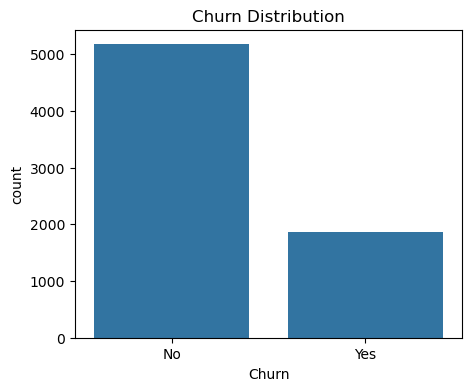

In [44]:
#Target Variabledf['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [52]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [60]:
#Calculation of imbalance
target_counts = df['Churn'].value_counts()
print("Class distribution:\n", target_counts)
imbalance_ratio = target_counts.max() / target_counts.min()
print("Imbalance ratio:", imbalance_ratio)

Class distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64
Imbalance ratio: 2.7683253076511503


In [68]:
#Imputation
from sklearn.impute import SimpleImputer
X = df.drop('Churn', axis=1)
y = df['Churn']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
num_imputer = SimpleImputer(strategy='mean')
X[num_cols] = num_imputer.fit_transform(X[num_cols])
cat_cols = X.select_dtypes(include=['object']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [134]:
#Feature Encoding, Column Transformation and Scaling (Preprocessing)
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

In [136]:
#PCA

from sklearn.decomposition import PCA
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_prepared)
X_test_pca = pca.transform(X_test_prepared)

In [140]:
#SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=0)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)
from collections import Counter
print("Before Smote:", Counter(y_train))
print("After Smote:", Counter(y_train_resampled))

Before Smote: Counter({0: 4139, 1: 1495})
After Smote: Counter({0: 4139, 1: 4139})


In [142]:
#Method 1: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_resampled, y_train_resampled)
y_pred = logreg.predict(X_test_pca)

#Evaluation of model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7444996451383961
Confusion Matrix:
 [[771 264]
 [ 96 278]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.74      0.81      1035
           1       0.51      0.74      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.74      0.76      1409



In [146]:
#Method 2: Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
rf = RandomForestClassifier(n_estimators=200,random_state=0)

rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test_pca)

#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Accuracy: 0.7686302342086586
Confusion Matrix:
 [[856 179]
 [147 227]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.61      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



In [150]:
#LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(shrinkage=None)
lda.fit(X_train_resampled, y_train_resampled)
y_pred_lda = lda.predict(X_test_pca)

#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lda))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lda))
print("Classification Report:\n", classification_report(y_test, y_pred_lda))

Accuracy: 0.7395315826827538
Confusion Matrix:
 [[756 279]
 [ 88 286]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



In [157]:
#QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_resampled, y_train_resampled)
y_pred_qda = qda.predict(X_test_pca)
#Evlauation
print("Accuracy:", accuracy_score(y_test, y_pred_qda))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_qda))
print("Classification Report:\n", classification_report(y_test, y_pred_qda))

Accuracy: 0.7622427253371186
Confusion Matrix:
 [[799 236]
 [ 99 275]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [159]:
#Choosing the right model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
models = {
    "LDA": y_pred_lda,
    "QDA": y_pred_qda,
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf
}

for name, y_pred in models.items():
    print(f"{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

LDA
Accuracy: 0.7395315826827538
Precision: 0.5061946902654867
Recall: 0.7647058823529411
F1-score: 0.6091586794462194
ROC-AUC: 0.7475703324808184
Confusion Matrix:
 [[756 279]
 [ 88 286]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409

QDA
Accuracy: 0.7622427253371186
Precision: 0.538160469667319
Recall: 0.7352941176470589
F1-score: 0.6214689265536724
ROC-AUC: 0.7536373969877807
Confusion Matrix:
 [[799 236]
 [ 99 275]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71     

In [166]:
#Accuracy: RFC most accurate 77%
#Precision: RFC most precise, 56%... LDA and LR give more false positives (correct positive predictions)
#Recall: LDA highest- 76% (catches most positive cases)
#F1: QDA best- 62% (catches positives and avoids negatives)
#ROC-AUC: QDA & LDA ~75% (discriminates classes well)

In [164]:
# ---> Best: QDA (f1 and roc-auc)
# ---> Most accurate (RFC... not ideal if minority positive matters)

In [168]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns  
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=20)),  
    ('smote', SMOTE(random_state=0)),
    ('classifier', QuadraticDiscriminantAnalysis())
])

param_grid = {
    'classifier__reg_param': [0.0, 0.1, 0.2, 0.5],
    'classifier__store_covariance': [True, False]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

# 🔹 Evaluation
y_pred = grid.predict(X_test)
print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Params: {'classifier__reg_param': 0.0, 'classifier__store_covariance': True}
Accuracy: 0.7622427253371186
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409

